<a href="https://colab.research.google.com/github/magish-gautam/Assestment-1-Concept-of-AI/blob/Workshop-2/Assestment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Human_Development_Index_Dataset.csv to Human_Development_Index_Dataset.csv
Dataset Loaded!
   Unnamed: 0 iso3      country  year    hdi  life_expectancy  pop_millions  \
0           1  AFG  Afghanistan  1990  0.284           45.967     10.694796   
1           2  AFG  Afghanistan  1991  0.292           46.663     10.745167   
2           3  AFG  Afghanistan  1992  0.299           47.596     12.057433   
3           4  AFG  Afghanistan  1993  0.307           51.466     14.003760   
4           5  AFG  Afghanistan  1994  0.300           51.495     15.455554   

   hdi_f  hdi_m  life_expec_f  life_expec_m  expec_yr_school  \
0    NaN    NaN        48.397        43.709         2.936460   
1    NaN    NaN        49.144        44.353         3.228456   
2    NaN    NaN        50.320        45.070         3.520452   
3    NaN    NaN        52.739        50.216         3.812448   
4    NaN    NaN        53.544        49.531         4.104445   

   expec_yr_school_f  expec_yr_school_m  m

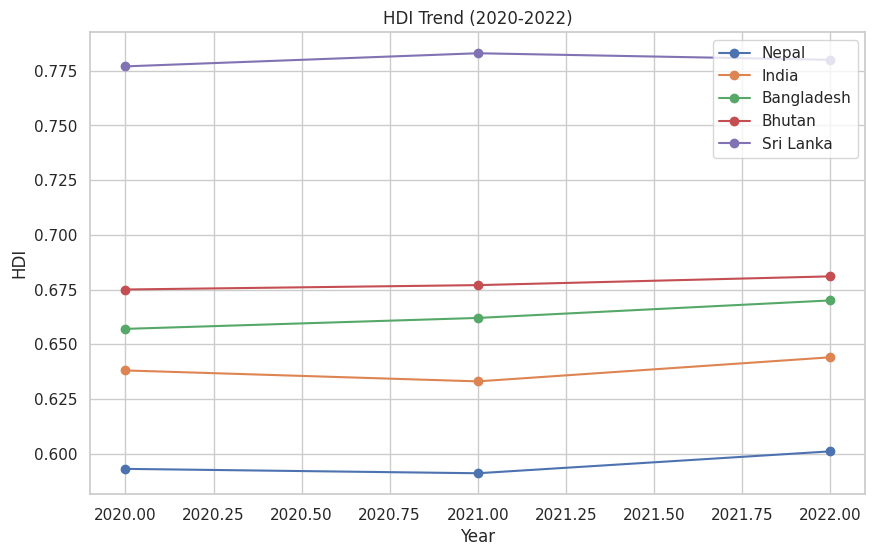

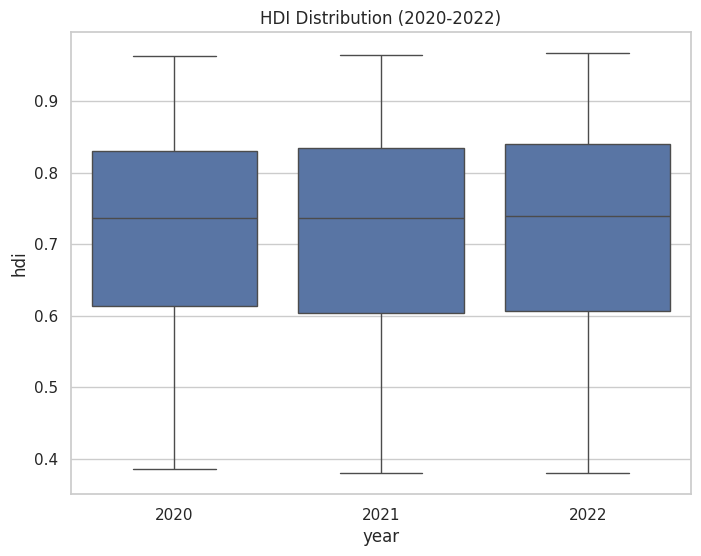

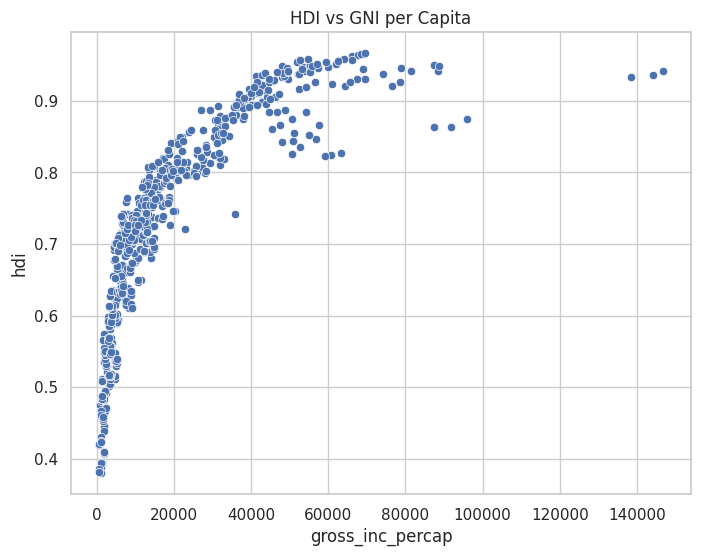

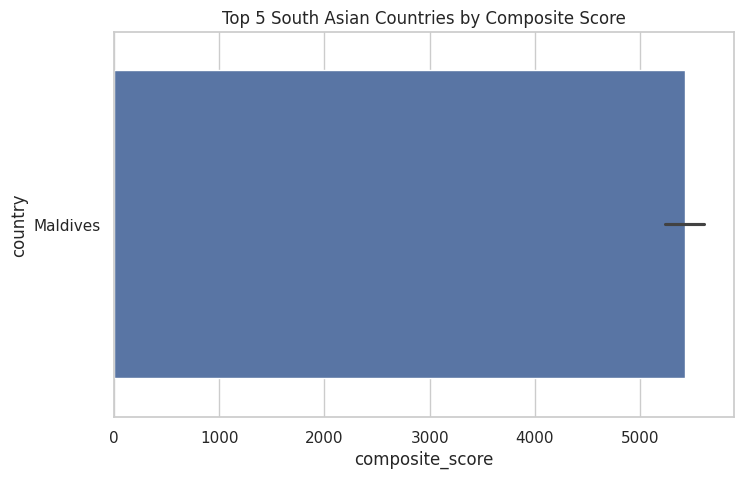

Outliers:
 Empty DataFrame
Columns: [country, hdi]
Index: []
Pearson correlation of life_expectancy with HDI: 0.96
Pearson correlation of gender_development with HDI: 0.87
Top 3 GNI-HDI gaps:
        country  gni_hdi_gap
3530  Maldives  18846.03019
3527  Maldives  18679.17236
3526  Maldives  18054.97765
Bottom 3 GNI-HDI gaps:
         country  gni_hdi_gap
11  Afghanistan   980.789554
10  Afghanistan  1047.002686
9   Afghanistan  1121.985570
South Asia HDI mean/std:
 mean    0.639583
std     0.098273
Name: hdi, dtype: float64
Middle East HDI mean/std:
 mean    0.788909
std     0.141295
Name: hdi, dtype: float64
South Asia Top 3:
         country    hdi
5476  Sri Lanka  0.783
5477  Sri Lanka  0.780
5475  Sri Lanka  0.777
South Asia Bottom 3:
         country    hdi
32  Afghanistan  0.462
31  Afghanistan  0.473
30  Afghanistan  0.488
Middle East Top 3:
                    country    hdi
6104  United Arab Emirates  0.937
6103  United Arab Emirates  0.931
6102  United Arab Emirates  0.930
M

In [ ]:
# =========================================
# Assignment 1: HDI Statistical Interpretation and EDA
# Student: [Magish Gautam]
# =========================================

# -------------------------
# Import Libraries
# -------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

# -------------------------
# Upload CSV (Colab-friendly)
# -------------------------
from google.colab import files
uploaded = files.upload()  # Select your CSV file

csv_file = list(uploaded.keys())[0]

# -------------------------
# Load Dataset with proper encoding
# -------------------------
try:
    hdi_df = pd.read_csv(csv_file, encoding='utf-8')
except UnicodeDecodeError:
    hdi_df = pd.read_csv(csv_file, encoding='latin1')  # fallback for Windows/Excel CSVs

print("Dataset Loaded!")
print(hdi_df.head())
print("\nColumns:", hdi_df.columns)

# -------------------------
# Ensure correct column names
# -------------------------
hdi_df.columns = [col.strip().lower().replace(" ", "_") for col in hdi_df.columns]

# Convert numeric columns
numeric_cols = ['year', 'hdi', 'life_expectancy', 'gross_inc_percap', 'education', 'gender_development']
for col in numeric_cols:
    if col in hdi_df.columns:
        hdi_df[col] = pd.to_numeric(hdi_df[col].replace(',', '', regex=True), errors='coerce')

# -------------------------
# Problem 1A: Single Year HDI Exploration (2022)
# -------------------------
hdi_2022_df = hdi_df[hdi_df['year'] == 2022].copy()
hdi_2022_df.drop_duplicates(inplace=True)

# Basic stats
print("HDI 2022 shape:", hdi_2022_df.shape)
print("Missing values:\n", hdi_2022_df.isnull().sum())

mean_hdi = hdi_2022_df['hdi'].mean()
median_hdi = hdi_2022_df['hdi'].median()
std_hdi = hdi_2022_df['hdi'].std()
print(f"HDI Mean: {mean_hdi:.3f}, Median: {median_hdi:.3f}, Std: {std_hdi:.3f}")

# Highest and lowest HDI countries
if 'hdi' in hdi_2022_df.columns:
    max_hdi_country = hdi_2022_df.loc[hdi_2022_df['hdi'].idxmax(), 'country']
    min_hdi_country = hdi_2022_df.loc[hdi_2022_df['hdi'].idxmin(), 'country']
    print("Highest HDI:", max_hdi_country)
    print("Lowest HDI:", min_hdi_country)

# HDI category
def hdi_category(hdi):
    if hdi < 0.550: return 'Low'
    elif hdi < 0.700: return 'Medium'
    elif hdi < 0.800: return 'High'
    else: return 'Very High'

hdi_2022_df['hdi_category'] = hdi_2022_df['hdi'].apply(hdi_category)
hdi_2022_df.to_csv('HDI_category_added.csv', index=False)

# Top HDI countries with GNI
if 'gross_inc_percap' in hdi_2022_df.columns:
    high_hdi_df = hdi_2022_df[hdi_2022_df['hdi'] > 0.800].sort_values('gross_inc_percap', ascending=False)
    print("Top 10 high HDI countries by GNI:\n", high_hdi_df[['country','hdi','gross_inc_percap']].head(10))

# -------------------------
# Problem 1B: HDI Trend Analysis (2020-2022)
# -------------------------
hdi_2020_2022_df = hdi_df[hdi_df['year'].isin([2020, 2021, 2022])].copy()
hdi_2020_2022_df.drop_duplicates(inplace=True)

# Line chart for example countries
countries = ['Nepal','India','Bangladesh','Bhutan','Sri Lanka']
plt.figure(figsize=(10,6))
for country in countries:
    subset = hdi_2020_2022_df[hdi_2020_2022_df['country'] == country].dropna(subset=['hdi'])
    plt.plot(subset['year'], subset['hdi'], marker='o', label=country)
plt.title('HDI Trend (2020-2022)')
plt.xlabel('Year')
plt.ylabel('HDI')
plt.legend()
plt.show()

# Average HDI by Region (bar chart)
if 'region' in hdi_2020_2022_df.columns:
    region_avg = hdi_2020_2022_df.groupby(['region','year'])['hdi'].mean().reset_index()
    plt.figure(figsize=(10,6))
    sns.barplot(x='region', y='hdi', hue='year', data=region_avg)
    plt.xticks(rotation=45)
    plt.title('Average HDI by Region (2020-2022)')
    plt.show()

# Box plot HDI distribution
plt.figure(figsize=(8,6))
sns.boxplot(x='year', y='hdi', data=hdi_2020_2022_df)
plt.title('HDI Distribution (2020-2022)')
plt.show()

# Scatter: HDI vs GNI
if 'gross_inc_percap' in hdi_2020_2022_df.columns:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x='gross_inc_percap', y='hdi', data=hdi_2020_2022_df)
    plt.title('HDI vs GNI per Capita')
    plt.show()

# -------------------------
# Problem 2: South Asia Analysis
# -------------------------
south_asia = ["Afghanistan", "Bangladesh", "Bhutan", "India",
              "Maldives", "Nepal", "Pakistan", "Sri Lanka"]
hdi_southasia = hdi_df[hdi_df['country'].isin(south_asia)].copy()
hdi_southasia.to_csv('HDI_SouthAsia.csv', index=False)

# Composite Score (using life expectancy & GNI)
for col in ['life_expectancy','gross_inc_percap']:
    hdi_southasia[col] = pd.to_numeric(hdi_southasia[col], errors='coerce')
hdi_southasia['composite_score'] = 0.3*hdi_southasia['life_expectancy'] + 0.3*hdi_southasia['gross_inc_percap']

# Top 5 composite score plot
top5 = hdi_southasia.sort_values('composite_score', ascending=False).head(5)
plt.figure(figsize=(8,5))
sns.barplot(x='composite_score', y='country', data=top5)
plt.title('Top 5 South Asian Countries by Composite Score')
plt.show()

# Outliers using 1.5*IQR
Q1 = hdi_southasia['hdi'].quantile(0.25)
Q3 = hdi_southasia['hdi'].quantile(0.75)
IQR = Q3 - Q1
outliers = hdi_southasia[(hdi_southasia['hdi'] < Q1-1.5*IQR) | (hdi_southasia['hdi'] > Q3+1.5*IQR)]
print("Outliers:\n", outliers[['country','hdi']])

# Correlation
for m in ['life_expectancy','gender_development']:
    if m in hdi_southasia.columns:
        corr = hdi_southasia[m].corr(hdi_southasia['hdi'])
        print(f"Pearson correlation of {m} with HDI: {corr:.2f}")

# GNI-HDI Gap
hdi_southasia['gni_hdi_gap'] = hdi_southasia['gross_inc_percap'] - hdi_southasia['hdi']
print("Top 3 GNI-HDI gaps:\n", hdi_southasia.sort_values('gni_hdi_gap', ascending=False).head(3)[['country','gni_hdi_gap']])
print("Bottom 3 GNI-HDI gaps:\n", hdi_southasia.sort_values('gni_hdi_gap').head(3)[['country','gni_hdi_gap']])

# -------------------------
# Problem 3: South Asia vs Middle East
# -------------------------
middle_east = ["Bahrain", "Iran", "Iraq", "Israel", "Jordan",
               "Kuwait", "Lebanon", "Oman", "Palestine", "Qatar",
               "Saudi Arabia", "Syria", "United Arab Emirates", "Yemen"]

hdi_middleeast = hdi_2020_2022_df[hdi_2020_2022_df['country'].isin(middle_east)].copy()
hdi_southasia_2020_2022 = hdi_2020_2022_df[hdi_2020_2022_df['country'].isin(south_asia)].copy()

# Descriptive statistics
print("South Asia HDI mean/std:\n", hdi_southasia_2020_2022['hdi'].agg(['mean','std']))
print("Middle East HDI mean/std:\n", hdi_middleeast['hdi'].agg(['mean','std']))

# Top/Bottom performers
def top_bottom(df, region_name):
    top3 = df.sort_values('hdi', ascending=False).head(3)
    bottom3 = df.sort_values('hdi').head(3)
    print(f"{region_name} Top 3:\n", top3[['country','hdi']])
    print(f"{region_name} Bottom 3:\n", bottom3[['country','hdi']])
top_bottom(hdi_southasia_2020_2022, "South Asia")
top_bottom(hdi_middleeast, "Middle East")

# HDI Disparity
for region, df in zip(['South Asia','Middle East'], [hdi_southasia_2020_2022, hdi_middleeast]):
    hdi_range = df['hdi'].max(skipna=True) - df['hdi'].min(skipna=True)
    cv = df['hdi'].std(skipna=True)/df['hdi'].mean(skipna=True)
    print(f"{region} HDI range: {hdi_range:.2f}, Coefficient of Variation: {cv:.2f}")


In [ ]:
%cd /content
!mkdir Assestment-1-AI
%cd Assestment-1-AI
!git init


/content
/content/Assestment-1-AI
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/Assestment-1-AI/.git/
